In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import shap
import warnings
import os
import time

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb06'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

Panel: 703,087 x 59


In [2]:
# 1. Feature Preparation

# Target variable
TARGET = 'crime_total'

# Feature columns (exclude targets, identifiers, leaky features)
exclude_cols = [
    'community_area', 'date', 'covid_phase', 'lisa_cluster',
    # All Y variables (avoid leakage)
    'crime_total', 'crime_violent', 'crime_property',
    'crime_theft', 'crime_battery', 'crime_homicide',
    'crime_burglary', 'crime_mvt', 'crime_narcotics',
    'crime_robbery', 'crime_assault',
    'arrest_count', 'domestic_count', 'arrest_rate',
]

feature_cols = [c for c in panel.columns if c not in exclude_cols]
print(f"Features ({len(feature_cols)}):")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:>2d}. {c}")

# %%
# Drop rows with NaN in features (lag features have leading NaN)
df = panel.dropna(subset=[TARGET]).copy()
print(f"\nAfter dropping NaN: {len(df):,} rows (dropped {len(panel)-len(df):,})")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")


Features (41):
   1. year
   2. month
   3. day_of_week
   4. day_of_year
   5. is_weekend
   6. post_covid
   7. covid_year
   8. temp_max
   9. temp_min
  10. temp_mean
  11. precipitation
  12. windspeed_max
  13. crowded_housing_pct
  14. poverty_rate
  15. unemployment_rate
  16. no_highschool_pct
  17. per_capita_income
  18. hardship_index
  19. is_high_crime_cluster
  20. crime_lag_1d
  21. crime_lag_7d
  22. crime_lag_14d
  23. crime_lag_30d
  24. crime_rolling_7d
  25. crime_rolling_30d
  26. city_avg_crime
  27. mob_retail
  28. mob_grocery
  29. mob_parks
  30. mob_transit
  31. mob_workplace
  32. mob_residential
  33. covid_cases
  34. covid_deaths
  35. covid_hosp
  36. covid_cases_7d
  37. covid_deaths_7d
  38. covid_hosp_7d
  39. unemployment_monthly
  40. mob_composite
  41. is_holiday

After dropping NaN: 703,087 rows (dropped 0)
Date range: 2001-01-01 to 2025-12-31


Train: 618,695 rows
Test:  56,287 rows
Val:   28,105 rows
2001-01-01 00:00:00 2022-12-31 00:00:00
2023-01-01 00:00:00 2024-12-31 00:00:00
2025-01-01 00:00:00 2025-12-31 00:00:00
Training baseline XGBoost...
Training time: 2.8s

Baseline Results:
  Test 2023-24    RMSE=3.420  MAE=2.477  R²=0.8223
  Val 2025        RMSE=3.376  MAE=2.422  R²=0.8020
Computing SHAP values (baseline model)...


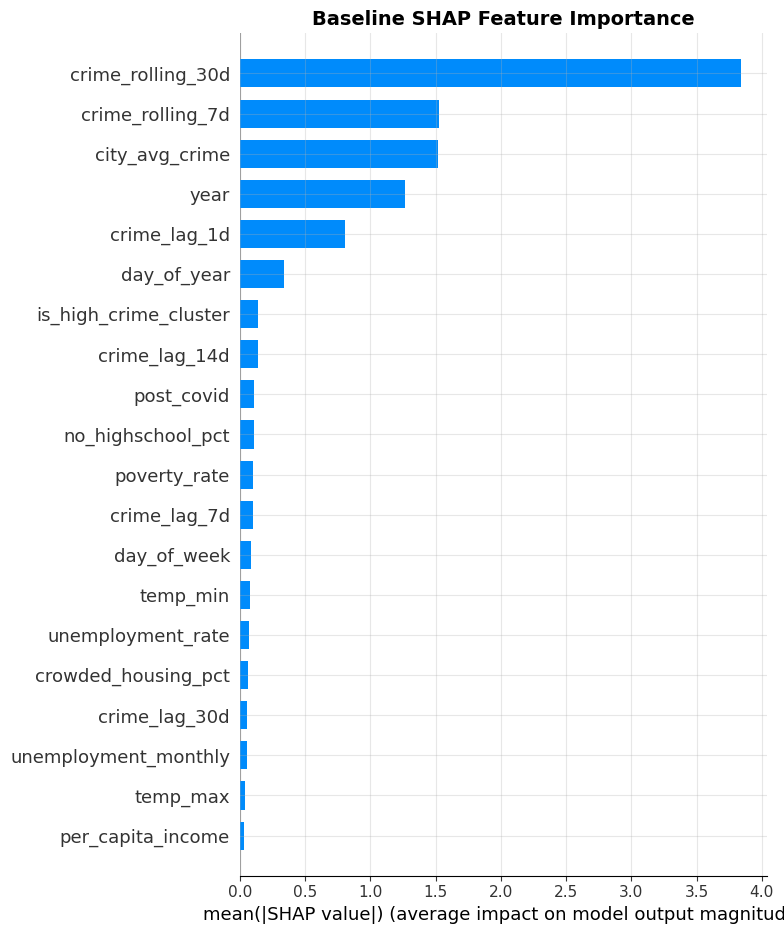

In [3]:
# 2. Baseline Model: Standard Train/Test Split

# Train on 2001-2022, test on 2023-2024, validate on 2025.
# This establishes a baseline R² to compare against rolling window.

train = df[df['year'] <= 2022]
test = df[(df['year'] >= 2023) & (df['year'] <= 2024)]
val = df[df['year'] == 2025]

X_train, y_train = train[feature_cols].fillna(0), train[TARGET]
X_test, y_test = test[feature_cols].fillna(0), test[TARGET]
X_val, y_val = val[feature_cols].fillna(0), val[TARGET]

print(f"Train: {len(train):,} rows")
print(f"Test:  {len(test):,} rows")
print(f"Val:   {len(val):,} rows")
print(train['date'].min(), train['date'].max())
print(test['date'].min(), test['date'].max())
print(val['date'].min(), val['date'].max())

# XGBoost with tuned hyperparameters
model_baseline = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

print("Training baseline XGBoost...")
t0 = time.time()
model_baseline.fit(X_train, y_train,
                   eval_set=[(X_test, y_test)],
                   verbose=False)
print(f"Training time: {time.time()-t0:.1f}s")

# Evaluate
y_pred_test = model_baseline.predict(X_test)
y_pred_val = model_baseline.predict(val[feature_cols])

def eval_metrics(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"  {label:<15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

print("\nBaseline Results:")
test_metrics = eval_metrics(y_test, y_pred_test, "Test 2023-24")
val_metrics = eval_metrics(val[TARGET], y_pred_val, "Val 2025")

# 2.1 Baseline SHAP Analysis

print("Computing SHAP values (baseline model)...")
explainer = shap.TreeExplainer(model_baseline)
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  max_display=20, show=False)
plt.title('Baseline SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_baseline_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


Total year-months: 300
Range: 200101 to 202512
Monthly rows: 23,100
Monthly candidate features: 32
Monthly features used: 24
Rolling window: 24 months train, predict next month
Total possible windows: ~275
  Window 1: train=200101-200212, feature_month=200301, predict=200302, R²=-0.112 RMSE=12.858
  Window 25: train=200301-200412, feature_month=200501, predict=200502, R²=0.977 RMSE=1.811
  Window 49: train=200501-200612, feature_month=200701, predict=200702, R²=0.938 RMSE=2.686
  Window 73: train=200701-200812, feature_month=200901, predict=200902, R²=0.962 RMSE=2.154
  Window 97: train=200901-201012, feature_month=201101, predict=201102, R²=0.880 RMSE=2.978
  Window 121: train=201101-201212, feature_month=201301, predict=201302, R²=0.946 RMSE=1.927
  Window 145: train=201301-201412, feature_month=201501, predict=201502, R²=0.924 RMSE=1.746
  Window 169: train=201501-201612, feature_month=201701, predict=201702, R²=0.969 RMSE=1.325
  Window 193: train=201701-201812, feature_month=20190

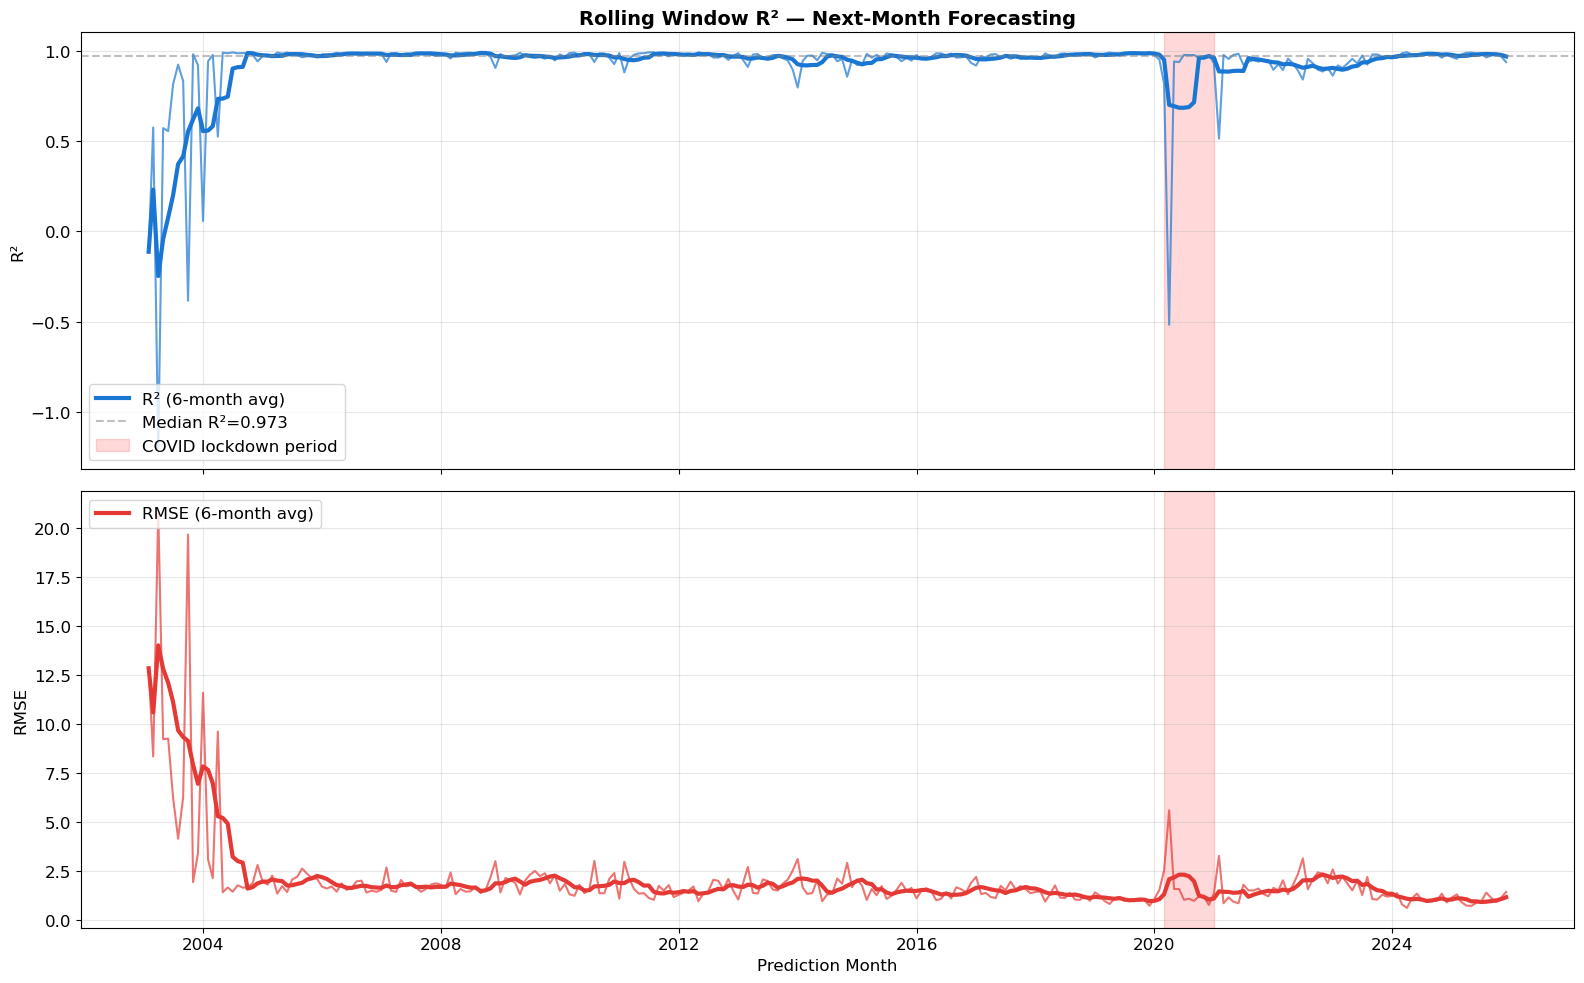

Concept Drift Analysis:
  Pre-COVID R²:    0.9328 (median 0.9759)
  During COVID R²: 0.7998 (median 0.9570)
  Post-COVID R²:   0.9430 (median 0.9581)

  R² drop during COVID: 0.1330


In [4]:
# 3. Rolling Window Forecasting + Concept Drift Detection
# **Innovation**: Train XGBoost on a 2-year rolling window, using month t features to predict crime in month t+1. Slide the window forward by 1 month.
# Track R²/RMSE over time to detect concept drift — especially around COVID-19.
# This reveals whether the model's predictive structure breaks down during regime changes, providing empirical evidence that COVID
# altered the data-generating process of crime.

# Aggregate to community-month for faster rolling window computation
# Exclude year/month because they are grouping keys
# Exclude high-risk crime-derived features that can make same-period monthly prediction too easy
drop_cols_for_monthly = [
    'year', 'month',
    'crime_lag_1d', 'crime_lag_7d', 'crime_lag_14d', 'crime_lag_30d',
    'crime_rolling_7d', 'crime_rolling_30d',
    'city_avg_crime'
]

monthly_feature_cols = [c for c in feature_cols if c not in drop_cols_for_monthly]

df_monthly = (df.groupby(['community_area', 'year', 'month'])
              .agg({TARGET: 'mean', **{c: 'mean' for c in monthly_feature_cols}})
              .reset_index())

# Create year-month identifier
df_monthly['date_ym'] = pd.to_datetime(
    df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str) + '-01'
)
df_monthly['ym'] = df_monthly['year'] * 100 + df_monthly['month']

# Sort and create next-month target
df_monthly = df_monthly.sort_values(['community_area', 'date_ym']).copy()
df_monthly['target_next_month'] = (
    df_monthly.groupby('community_area')[TARGET].shift(-1)
)

all_yms = sorted(df_monthly['ym'].unique())
print(f"Total year-months: {len(all_yms)}")
print(f"Range: {all_yms[0]} to {all_yms[-1]}")
print(f"Monthly rows: {len(df_monthly):,}")
print(f"Monthly candidate features: {len(monthly_feature_cols)}")

# Rolling window: train on 24 months, predict next 1 month
WINDOW_SIZE = 24  # months
rolling_results = []

# Keep monthly features with reasonable coverage
monthly_features = [c for c in monthly_feature_cols
                    if df_monthly[c].notna().mean() > 0.5]

print(f"Monthly features used: {len(monthly_features)}")
print(f"Rolling window: {WINDOW_SIZE} months train, predict next month")
print(f"Total possible windows: ~{len(all_yms) - WINDOW_SIZE - 1}")

for i in range(WINDOW_SIZE, len(all_yms) - 1):
    train_yms = all_yms[i-WINDOW_SIZE:i]
    test_ym = all_yms[i]

    train_rw = df_monthly[df_monthly['ym'].isin(train_yms)].dropna(
        subset=monthly_features + ['target_next_month']
    )
    test_rw = df_monthly[df_monthly['ym'] == test_ym].dropna(
        subset=monthly_features + ['target_next_month']
    )

    if len(train_rw) < 100 or len(test_rw) < 10:
        continue

    X_tr = train_rw[monthly_features].fillna(0)
    y_tr = train_rw['target_next_month']
    X_te = test_rw[monthly_features].fillna(0)
    y_te = test_rw['target_next_month']

    model_rw = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model_rw.fit(X_tr, y_tr, verbose=False)
    y_pred_rw = model_rw.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred_rw))
    mae = mean_absolute_error(y_te, y_pred_rw)
    r2 = r2_score(y_te, y_pred_rw)

    test_date = pd.Timestamp(f"{test_ym//100}-{test_ym%100:02d}-01")
    pred_month = test_date + pd.offsets.MonthBegin(1)

    rolling_results.append({
        'feature_month': test_date,          # month of features
        'test_date': pred_month,             # predicted month (t+1)
        'test_ym': int(pred_month.strftime('%Y%m')),
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'n_train': len(train_rw),
        'n_test': len(test_rw)
    })

    if (i - WINDOW_SIZE) % 24 == 0:
        print(
            f"  Window {i-WINDOW_SIZE+1}: "
            f"train={train_yms[0]}-{train_yms[-1]}, "
            f"feature_month={test_ym}, "
            f"predict={int(pred_month.strftime('%Y%m'))}, "
            f"R²={r2:.3f} RMSE={rmse:.3f}"
        )

rw_df = pd.DataFrame(rolling_results)
print(f"\nRolling window complete: {len(rw_df)} windows")
print(f"Prediction range: {rw_df['test_date'].min().date()} to {rw_df['test_date'].max().date()}")

#3.1 Concept Drift Visualization

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# R² over time
ax1 = axes[0]
ax1.plot(rw_df['test_date'], rw_df['r2'], '-', color='#1976D2', lw=1.5, alpha=0.7)
ax1.plot(rw_df['test_date'], rw_df['r2'].rolling(6, min_periods=1).mean(),
         '-', color='#1976D2', lw=3, label='R² (6-month avg)')
ax1.axhline(rw_df['r2'].median(), color='gray', ls='--', alpha=0.5,
            label=f"Median R²={rw_df['r2'].median():.3f}")
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
            alpha=0.15, color='red', label='COVID lockdown period')
ax1.set_ylabel('R²')
ax1.set_title('Rolling Window R² — Next-Month Forecasting', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left')

# RMSE over time
ax2 = axes[1]
ax2.plot(rw_df['test_date'], rw_df['rmse'], '-', color='#E53935', lw=1.5, alpha=0.7)
ax2.plot(rw_df['test_date'], rw_df['rmse'].rolling(6, min_periods=1).mean(),
         '-', color='#E53935', lw=3, label='RMSE (6-month avg)')
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
            alpha=0.15, color='red')
ax2.set_ylabel('RMSE')
ax2.set_xlabel('Prediction Month')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_concept_drift.png'), dpi=150, bbox_inches='tight')
plt.show()

# Quantify drift
pre_covid = rw_df[rw_df['test_date'] < '2020-03-01']
during_covid = rw_df[(rw_df['test_date'] >= '2020-03-01') & (rw_df['test_date'] <= '2020-12-31')]
post_covid = rw_df[rw_df['test_date'] > '2020-12-31']

print("Concept Drift Analysis:")
print(f"  Pre-COVID R²:    {pre_covid['r2'].mean():.4f} (median {pre_covid['r2'].median():.4f})")
print(f"  During COVID R²: {during_covid['r2'].mean():.4f} (median {during_covid['r2'].median():.4f})")
print(f"  Post-COVID R²:   {post_covid['r2'].mean():.4f} (median {post_covid['r2'].median():.4f})")
print(f"\n  R² drop during COVID: {pre_covid['r2'].mean() - during_covid['r2'].mean():.4f}")

Top 20% communities (n=16): high baseline crime
Bot 20% communities (n=16): low baseline crime
Running rolling window for Top 20%...
  Done: 275 windows
Running rolling window for Bot 20%...
  Done: 275 windows

=== Grouped Concept Drift Summary ===

Top 20% (high crime):
  Pre-COVID  R²: 0.8920
  During     R²: 0.2904  (drop = 0.6016)
  Post-COVID R²: 0.8459

Bot 20% (low crime):
  Pre-COVID  R²: 0.7329
  During     R²: 0.3592  (drop = 0.3737)
  Post-COVID R²: 0.6850

Difference in R² drop (Top - Bot): +0.2279


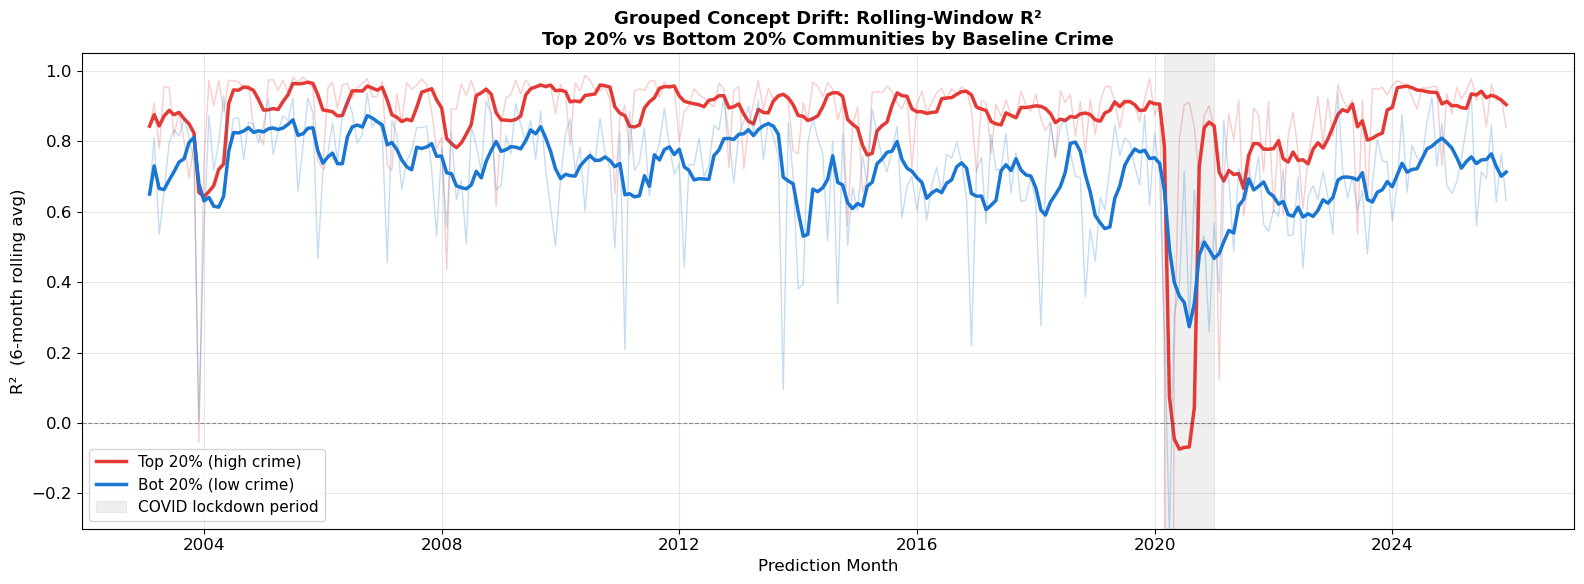

In [5]:
# 4. Grouped Concept Drift: Top 20% vs Bottom 20%

# Partition communities by pre-COVID baseline crime intensity (2017-2019 average).
# Run separate rolling-window forecasting for each group.
# Compare R² drop during COVID to test whether predictive instability
# was concentrated in high-crime communities.
# Grouping aligned with NB07 sensitivity analysis (Top20 vs Bot20).

# Step 1: Compute pre-COVID baseline crime per community (2017-2019)
baseline = panel[panel['year'].isin([2017, 2018, 2019])].copy()
baseline_crime = (
    baseline.groupby('community_area')['crime_total']
    .mean()
    .reset_index()
    .rename(columns={'crime_total': 'baseline_crime'})
)

# Step 2: Assign Top20 / Bottom20 labels
n_communities = baseline_crime.shape[0]  # 77
top_cutoff    = int(np.ceil(n_communities * 0.20))   # 16
bot_cutoff    = int(np.ceil(n_communities * 0.20))   # 16

baseline_crime = baseline_crime.sort_values('baseline_crime', ascending=False).reset_index(drop=True)
top20_communities = set(baseline_crime.iloc[:top_cutoff]['community_area'])
bot20_communities = set(baseline_crime.iloc[-bot_cutoff:]['community_area'])

print(f"Top 20% communities (n={len(top20_communities)}): high baseline crime")
print(f"Bot 20% communities (n={len(bot20_communities)}): low baseline crime")

# Step 3: Aggregate to community-month, separately for each group
def make_monthly(df_subset):
    df_subset = df_subset.copy()
    df_subset['ym'] = df_subset['date'].dt.year * 100 + df_subset['date'].dt.month
    monthly = df_subset.groupby(['community_area', 'ym']).agg(
        target_crime=('crime_total', 'mean'),
        temp_max=('temp_max', 'mean'),
        temp_min=('temp_min', 'mean'),
        precipitation=('precipitation', 'sum'),
        poverty_rate=('poverty_rate', 'first'),
        unemployment_rate=('unemployment_rate', 'first'),
        per_capita_income=('per_capita_income', 'first'),
        hardship_index=('hardship_index', 'first'),
    ).reset_index()
    monthly['target_next_month'] = monthly.groupby('community_area')['target_crime'].shift(-1)
    return monthly

panel_top = panel[panel['community_area'].isin(top20_communities)]
panel_bot = panel[panel['community_area'].isin(bot20_communities)]

monthly_top = make_monthly(panel_top)
monthly_bot = make_monthly(panel_bot)

# Step 4: Rolling window function (reusable)
WINDOW_SIZE = 24
monthly_features = [
    'temp_max', 'temp_min', 'precipitation',
    'poverty_rate', 'unemployment_rate',
    'per_capita_income', 'hardship_index', 'target_crime'
]

def run_rolling_window(df_monthly, label):
    all_yms = sorted(df_monthly['ym'].unique())
    results  = []

    for i in range(WINDOW_SIZE, len(all_yms) - 1):
        train_yms = all_yms[i - WINDOW_SIZE: i]
        test_ym   = all_yms[i]

        train = df_monthly[df_monthly['ym'].isin(train_yms)].dropna(
            subset=monthly_features + ['target_next_month']
        )
        test = df_monthly[df_monthly['ym'] == test_ym].dropna(
            subset=monthly_features + ['target_next_month']
        )

        if len(train) < 50 or len(test) < 5:
            continue

        X_tr = train[monthly_features].fillna(0)
        y_tr = train['target_next_month']
        X_te = test[monthly_features].fillna(0)
        y_te = test['target_next_month']

        m = xgb.XGBRegressor(
            n_estimators=100, max_depth=5,
            learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, random_state=42, n_jobs=-1
        )
        m.fit(X_tr, y_tr, verbose=False)
        y_pred = m.predict(X_te)

        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)

        test_date  = pd.Timestamp(f"{test_ym//100}-{test_ym%100:02d}-01")
        pred_month = test_date + pd.offsets.MonthBegin(1)

        results.append({
            'test_date': pred_month,
            'r2': r2, 'rmse': rmse,
            'group': label
        })

    return pd.DataFrame(results)

print("Running rolling window for Top 20%...")
rw_top = run_rolling_window(monthly_top, 'Top 20%')
print(f"  Done: {len(rw_top)} windows")

print("Running rolling window for Bot 20%...")
rw_bot = run_rolling_window(monthly_bot, 'Bot 20%')
print(f"  Done: {len(rw_bot)} windows")

# Step 5: Compute COVID-period R² drop for each group
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-12-31')

def summarise_drift(rw_df, label):
    pre    = rw_df[rw_df['test_date'] <  covid_start]['r2'].mean()
    during = rw_df[(rw_df['test_date'] >= covid_start) &
                   (rw_df['test_date'] <= covid_end)]['r2'].mean()
    post   = rw_df[rw_df['test_date'] >  covid_end]['r2'].mean()
    drop   = pre - during
    print(f"\n{label}:")
    print(f"  Pre-COVID  R²: {pre:.4f}")
    print(f"  During     R²: {during:.4f}  (drop = {drop:.4f})")
    print(f"  Post-COVID R²: {post:.4f}")
    return {'label': label, 'pre': pre, 'during': during,
            'post': post, 'drop': drop}

print("\n=== Grouped Concept Drift Summary ===")
summary_top = summarise_drift(rw_top, 'Top 20% (high crime)')
summary_bot = summarise_drift(rw_bot, 'Bot 20% (low crime)')
print(f"\nDifference in R² drop (Top - Bot): "
      f"{summary_top['drop'] - summary_bot['drop']:+.4f}")

# Step 6: Plot two R² curves on one figure
fig, ax = plt.subplots(figsize=(16, 6))

for rw_df, label, color in [
    (rw_top, 'Top 20% (high crime)', '#E53935'),
    (rw_bot, 'Bot 20% (low crime)',  '#1976D2'),
]:
    smooth = rw_df.set_index('test_date')['r2'].rolling('180D').mean()
    ax.plot(rw_df['test_date'], rw_df['r2'],
            alpha=0.25, color=color, lw=1)
    ax.plot(smooth.index, smooth.values,
            color=color, lw=2.5, label=label)

ax.axvspan(covid_start, covid_end,
           alpha=0.12, color='gray', label='COVID lockdown period')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_ylabel('R²  (6-month rolling avg)', fontsize=12)
ax.set_xlabel('Prediction Month', fontsize=12)
ax.set_title(
    'Grouped Concept Drift: Rolling-Window R²\n'
    'Top 20% vs Bottom 20% Communities by Baseline Crime',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.set_ylim(-0.3, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_grouped_concept_drift.png'),
            dpi=150, bbox_inches='tight')
plt.show()